## Understanding the Dataset

This notebook aims to explore and understand the dataset I am working with. At this stage, I will not manipulate the data or make any inferences. The objective is only to describe the dataset and analyze how the variables are distributed.

This dataset was provided by Kaggle.

In [2]:
!pip install pandas 
!pip install numpy
!pip install matplotlib
!pip install scipy


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [4]:
filepath = '../data/Teen_Mental_Health_Dataset.csv'
teen_health = pd.read_csv(filepath)

Let's describe the series:

In [5]:
teen_health.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [6]:
teen_health.shape


(1200, 13)

In [7]:
teen_health.sample(10)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
818,18,male,2.8,Instagram,6.9,2.3,3.11,0.1,medium,7,1,9,0
216,15,male,7.5,Instagram,8.1,2.5,3.56,1.2,medium,6,8,10,0
379,19,male,6.9,Instagram,5.0,1.2,2.56,1.6,high,3,10,8,0
942,15,female,2.6,Both,7.9,1.8,3.91,0.5,medium,4,5,6,0
427,15,female,2.7,Both,6.5,1.6,2.14,0.4,high,6,6,6,0
70,14,male,5.2,Both,6.7,2.0,3.48,1.0,medium,2,1,5,0
431,13,female,1.4,Both,7.8,0.6,3.42,1.6,medium,10,4,6,0
313,13,female,8.0,Instagram,5.4,2.8,3.10,1.9,high,6,10,10,0
666,16,female,2.8,TikTok,7.4,2.0,3.40,1.6,low,4,1,1,0
111,17,female,5.2,Both,6.0,0.6,3.07,0.6,medium,6,2,9,0


In [8]:
teen_health.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


## THE DATASET

Based on the results above we can say that the dataset has 1.200 teenagers, ages between 13-19, who use social media.It includes informations about their daily habtis related to the use of social media and how these behavior may relate to ther mental health. The study focuses on factors such as daily social media usage, screen time, physical activity, sleep patterns, and other lifestyle indicators to assess whether social media use may affect mental health.

## Columns Description

- age: the age of the student
- gender: the gender of the student
- daily_social_media_hours: the number of hours the student spends on social media each day
- platform_usage: the social media platform most used by the student
- sleep_hours: the number of hours the student sleeps daily
- screen_time_before_sleep: the amount of phone usage before sleeping
- academic_performance: the student’s academic performance
- physical_activity: the amount of exercise the student does each day
- social_interaction_level: the level of real-life social interaction of the student
- stress_level: the student’s stress level
- addiction_level: the level of social media addiction
- depression_label: the level or presence of depression symptoms

## Searching for empty values

In [9]:
teen_health.isnull().sum()


age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

In [10]:
teen_health.duplicated().sum()

np.int64(0)

It seems that the dataset doesn't contains empty values 


## Specific Analyses 



In [11]:
display(teen_health['gender'].value_counts())

gender
male      615
female    585
Name: count, dtype: int64

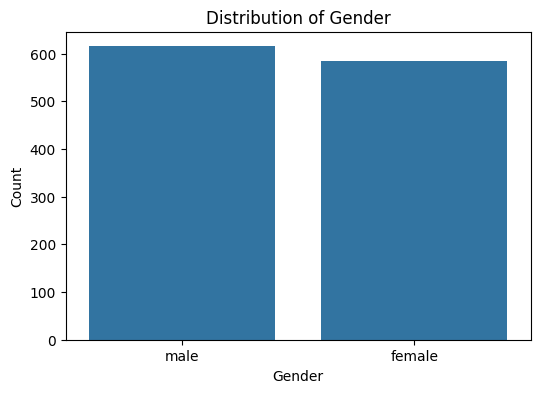

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(x='gender', data=teen_health)

plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

In [12]:
display(teen_health['platform_usage'].value_counts())

platform_usage
Instagram    411
TikTok       398
Both         391
Name: count, dtype: int64

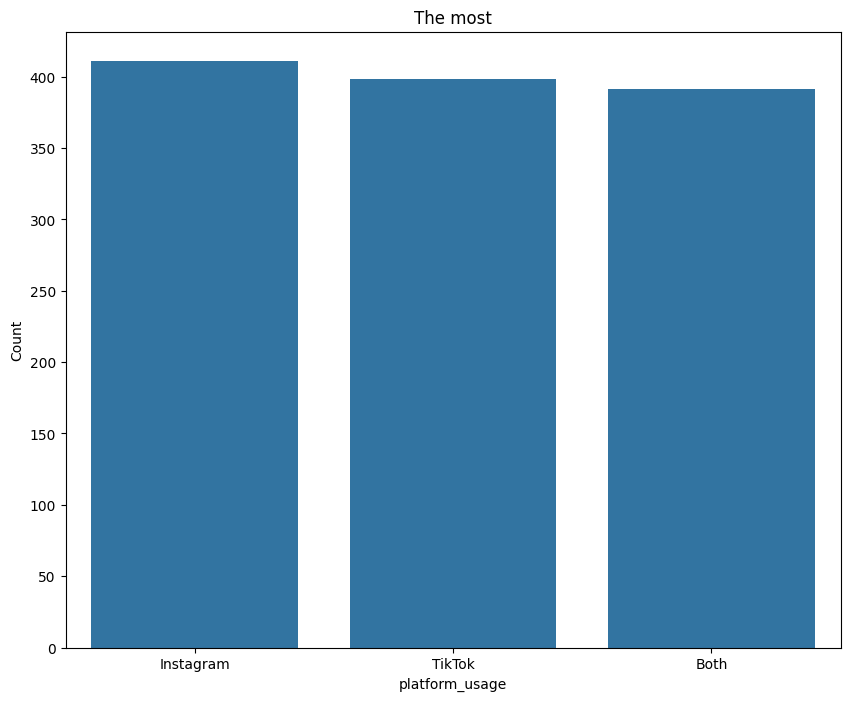

In [22]:
plt.figure(figsize=(10,8))

sns.countplot(x='platform_usage', data=teen_health)

plt.title('The most')
plt.ylabel('Count')
plt.show()

In [13]:
display(teen_health['social_interaction_level'].value_counts())

social_interaction_level
medium    416
low       415
high      369
Name: count, dtype: int64